# **Prepare Data**

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from autogluon.tabular import TabularPredictor
import zipfile
warnings.filterwarnings("ignore")

In [2]:
zipfile.ZipFile("/home/drasogun/DraSoGun/AI/SuperAI_ss6/Competitions/Ghouls-Goblins-And-Ghosts-Boo/train.csv.zip").extractall("train")
zipfile.ZipFile("/home/drasogun/DraSoGun/AI/SuperAI_ss6/Competitions/Ghouls-Goblins-And-Ghosts-Boo/test.csv.zip").extractall("test")

In [19]:
train_df = pd.read_csv("train/train.csv")
test_df = pd.read_csv("test/test.csv")

# **Explore Data**

## Data

In [4]:
train_df.head()

,id,bone_length,rotting_flesh,hair_length,has_soul,color,type
0,0,0.354512,0.350839,0.465761,0.781142,clear,Ghoul
1,1,0.575560,0.425868,0.531401,0.439899,green,Goblin
2,2,0.467875,0.354330,0.811616,0.791225,black,Ghoul
3,4,0.776652,0.508723,0.636766,0.884464,black,Ghoul
4,5,0.566117,0.875862,0.418594,0.636438,green,Ghost


In [5]:
test_df.head()

,id,bone_length,rotting_flesh,hair_length,has_soul,color
0,3,0.471774,0.387937,0.706087,0.698537,black
1,6,0.427332,0.645024,0.565558,0.451462,white
2,9,0.549602,0.491931,0.660387,0.449809,black
3,10,0.638095,0.682867,0.471409,0.356924,white
4,13,0.361762,0.583997,0.377256,0.276364,black


In [7]:
train_df.shape,test_df.shape

((371, 7), (529, 6))

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             371 non-null    int64  
 1   bone_length    371 non-null    float64
 2   rotting_flesh  371 non-null    float64
 3   hair_length    371 non-null    float64
 4   has_soul       371 non-null    float64
 5   color          371 non-null    object 
 6   type           371 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 20.4+ KB


## Statistics

In [8]:
train_df.describe()

,id,bone_length,rotting_flesh,hair_length,has_soul
count,371.000000,371.000000,371.000000,371.000000,371.000000
mean,443.676550,0.434160,0.506848,0.529114,0.471392
std,263.222489,0.132833,0.146358,0.169902,0.176129
min,0.000000,0.061032,0.095687,0.134600,0.009402
25%,205.500000,0.340006,0.414812,0.407428,0.348002
50%,458.000000,0.434891,0.501552,0.538642,0.466372
75%,678.500000,0.517223,0.603977,0.647244,0.600610
max,897.000000,0.817001,0.932466,1.000000,0.935721


In [9]:
test_df.describe()

,id,bone_length,rotting_flesh,hair_length,has_soul
count,529.000000,529.000000,529.000000,529.000000,529.000000
mean,453.584121,0.425474,0.503637,0.517288,0.464096
std,257.804948,0.136079,0.158552,0.171727,0.179659
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,239.000000,0.329383,0.393987,0.388189,0.338964
50%,445.000000,0.421989,0.510065,0.520220,0.461294
75%,670.000000,0.519024,0.605957,0.644824,0.584448
max,899.000000,1.000000,1.000000,0.999841,1.000000


## Balance

<Axes: xlabel='type', ylabel='count'>

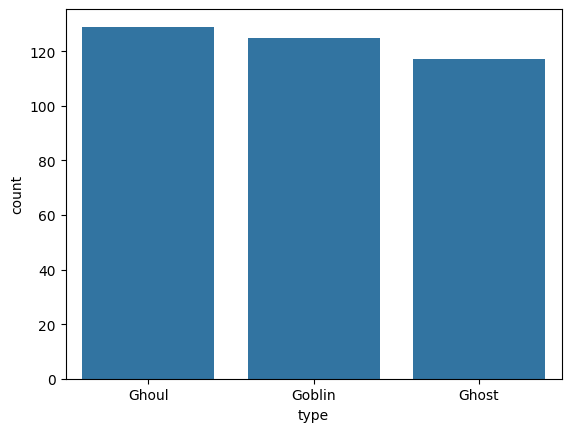

In [10]:
sns.countplot(data=train_df, x='type')

## Duplicate

In [11]:
features = train_df.columns.values[1:5]
features

array(['bone_length', 'rotting_flesh', 'hair_length', 'has_soul'],
      dtype=object)

In [15]:
train_dp = []
test_dp = []
for i in features:
    f = train_df[i].value_counts()
    train_dp.append([i,f.max(),f.idxmax()])
    f = test_df[i].value_counts()
    test_dp.append([i,f.max(),f.idxmax()])
train_dp = pd.DataFrame(train_dp,columns=["Feature","Dup","Value"])
test_dp = pd.DataFrame(test_dp,columns=["Feature","Dup","Value"])

In [14]:
train_dp

,Feature,Dup,Value
0,bone_length,1,0.670200
1,rotting_flesh,1,0.768469
2,hair_length,1,0.737274
3,has_soul,1,0.608384


In [16]:
test_dp

,Feature,Dup,Value
0,bone_length,1,0.256789
1,rotting_flesh,1,0.691802
2,hair_length,1,0.415197
3,has_soul,1,0.348971


# **Analysis Data**

In [20]:
map_data = {
    "Ghoul": 0,
    "Goblin": 1,
    "Ghost": 2
}
train_df['type'] = train_df['type'].map(map_data)
train_df

,id,bone_length,rotting_flesh,hair_length,has_soul,color,type
0,0,0.354512,0.350839,0.465761,0.781142,clear,0
1,1,0.575560,0.425868,0.531401,0.439899,green,1
2,2,0.467875,0.354330,0.811616,0.791225,black,0
3,4,0.776652,0.508723,0.636766,0.884464,black,0
4,5,0.566117,0.875862,0.418594,0.636438,green,2
...,...,...,...,...,...,...,...
366,886,0.458132,0.391760,0.660590,0.635689,blue,1
367,889,0.331936,0.564836,0.539216,0.551471,green,2
368,890,0.481640,0.501147,0.496446,0.544003,clear,0
369,896,0.294943,0.771286,0.583503,0.300618,clear,2


## Raw Data

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'bone_length'}>],
       [<Axes: title={'center': 'rotting_flesh'}>,
        <Axes: title={'center': 'hair_length'}>],
       [<Axes: title={'center': 'has_soul'}>, <Axes: >]], dtype=object)

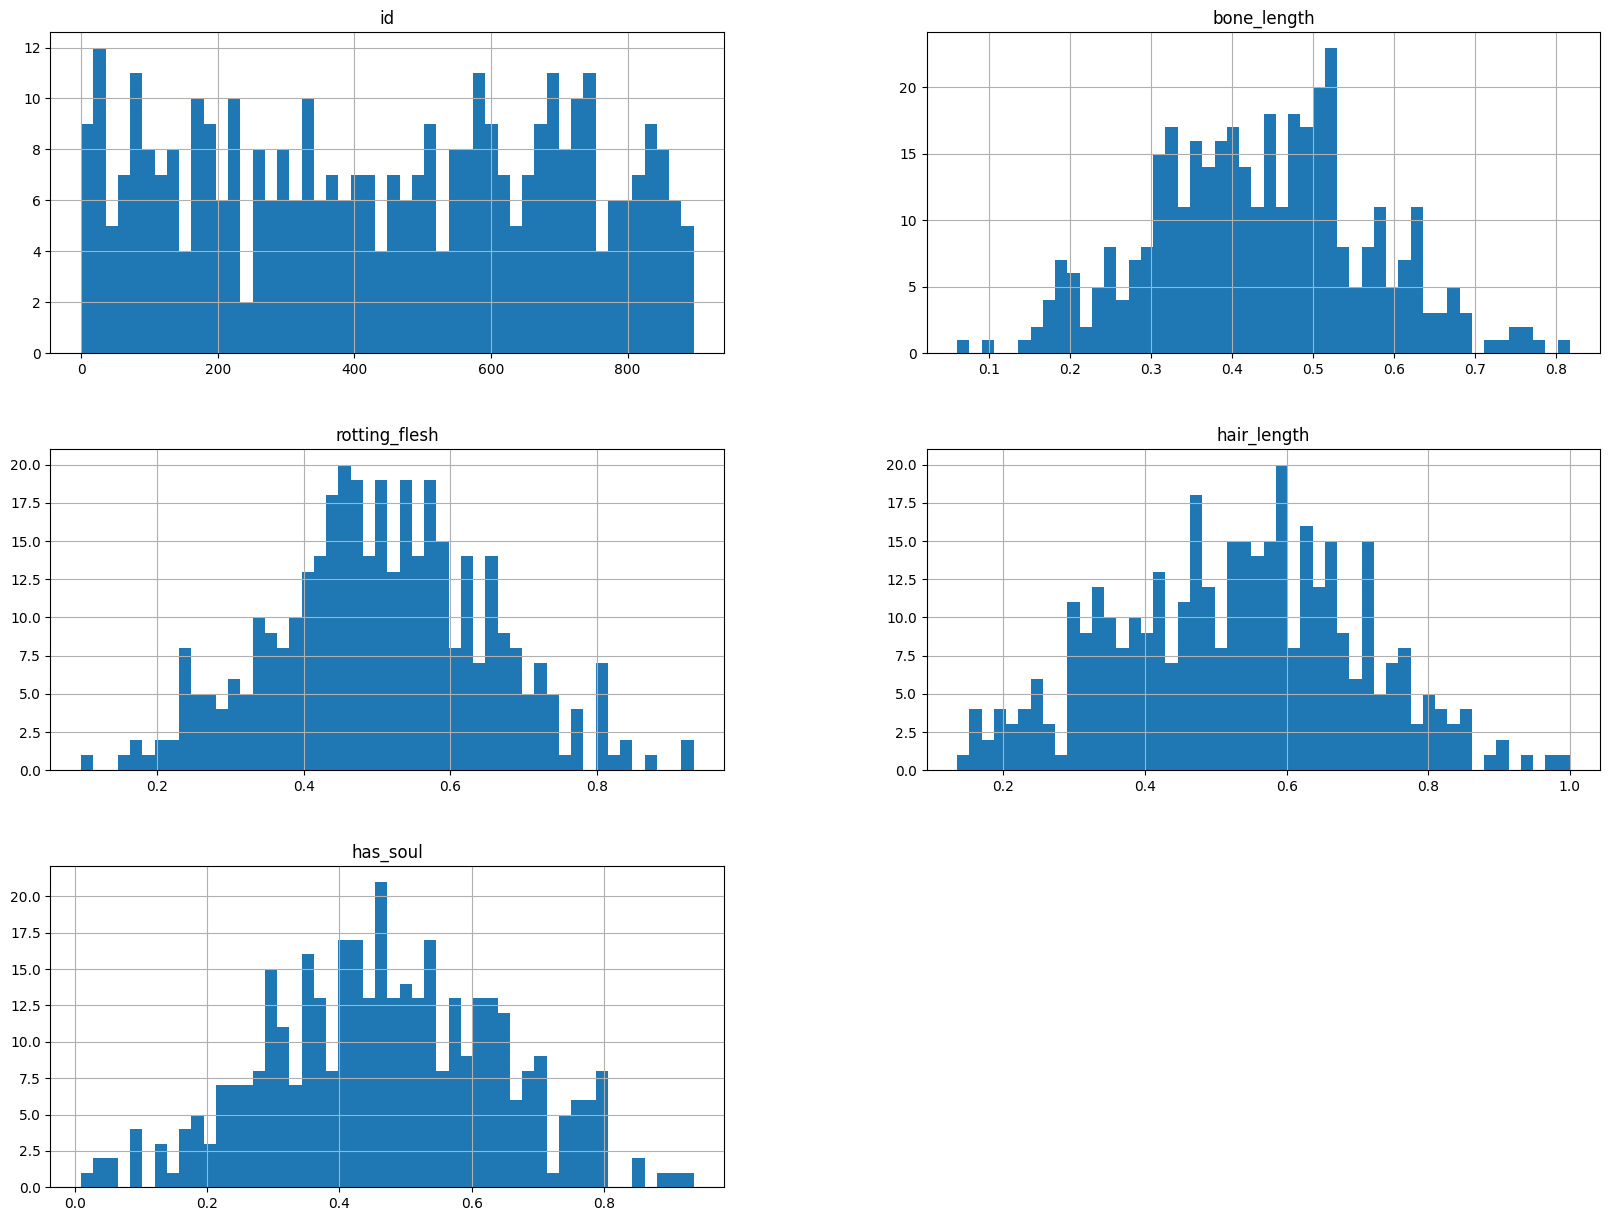

In [17]:
train_df.hist(bins=50, figsize=(20,15))

## Mean

<Figure size 640x480 with 0 Axes>

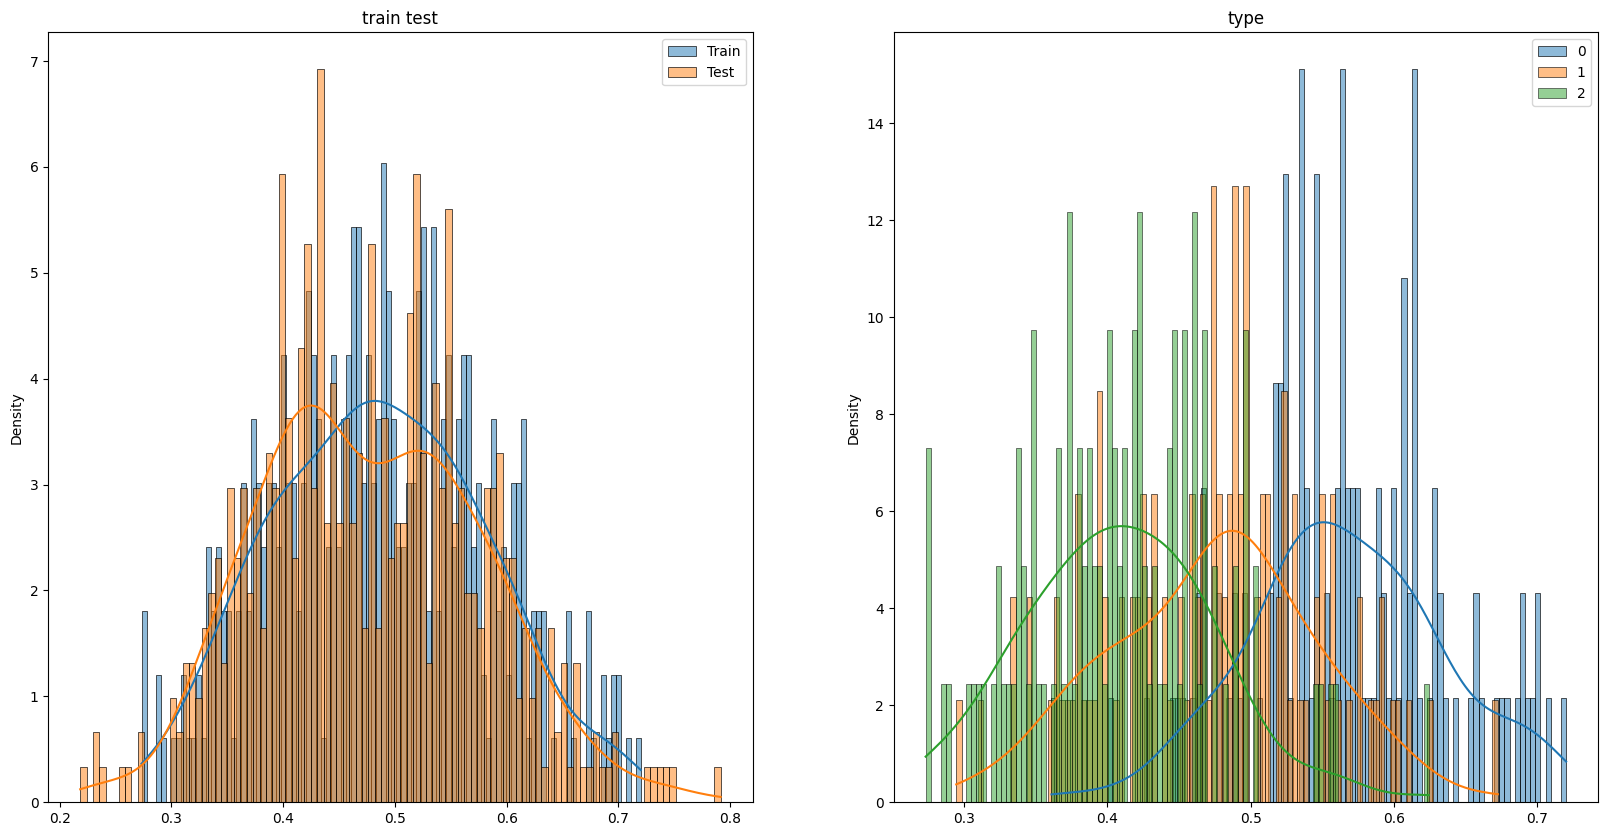

In [37]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].mean(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].mean(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].mean(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Standard division

<Figure size 640x480 with 0 Axes>

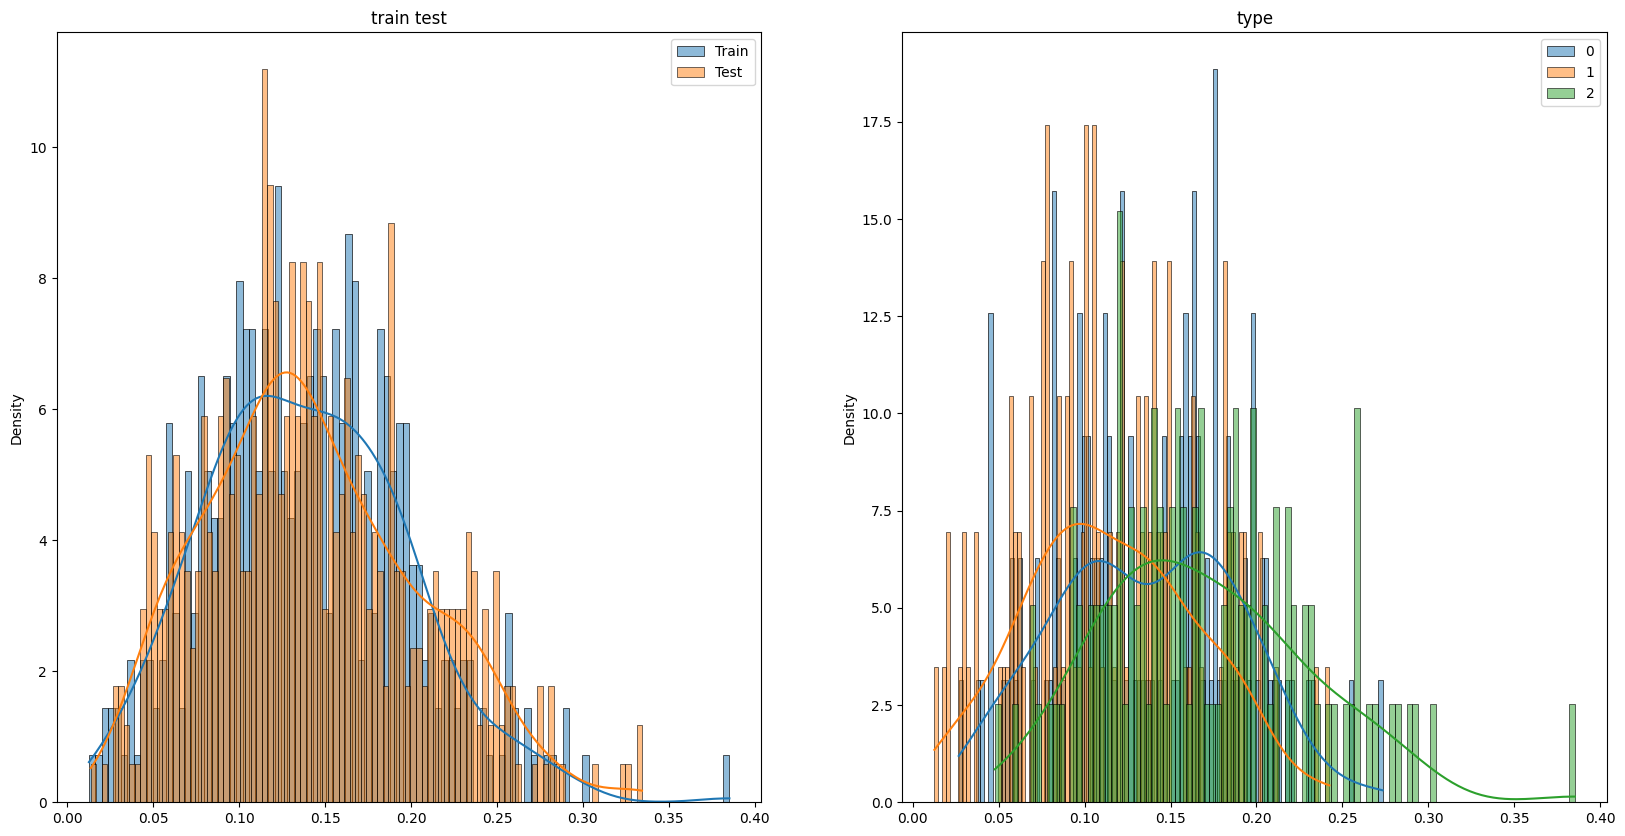

In [38]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].std(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].std(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].std(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Min

<Figure size 640x480 with 0 Axes>

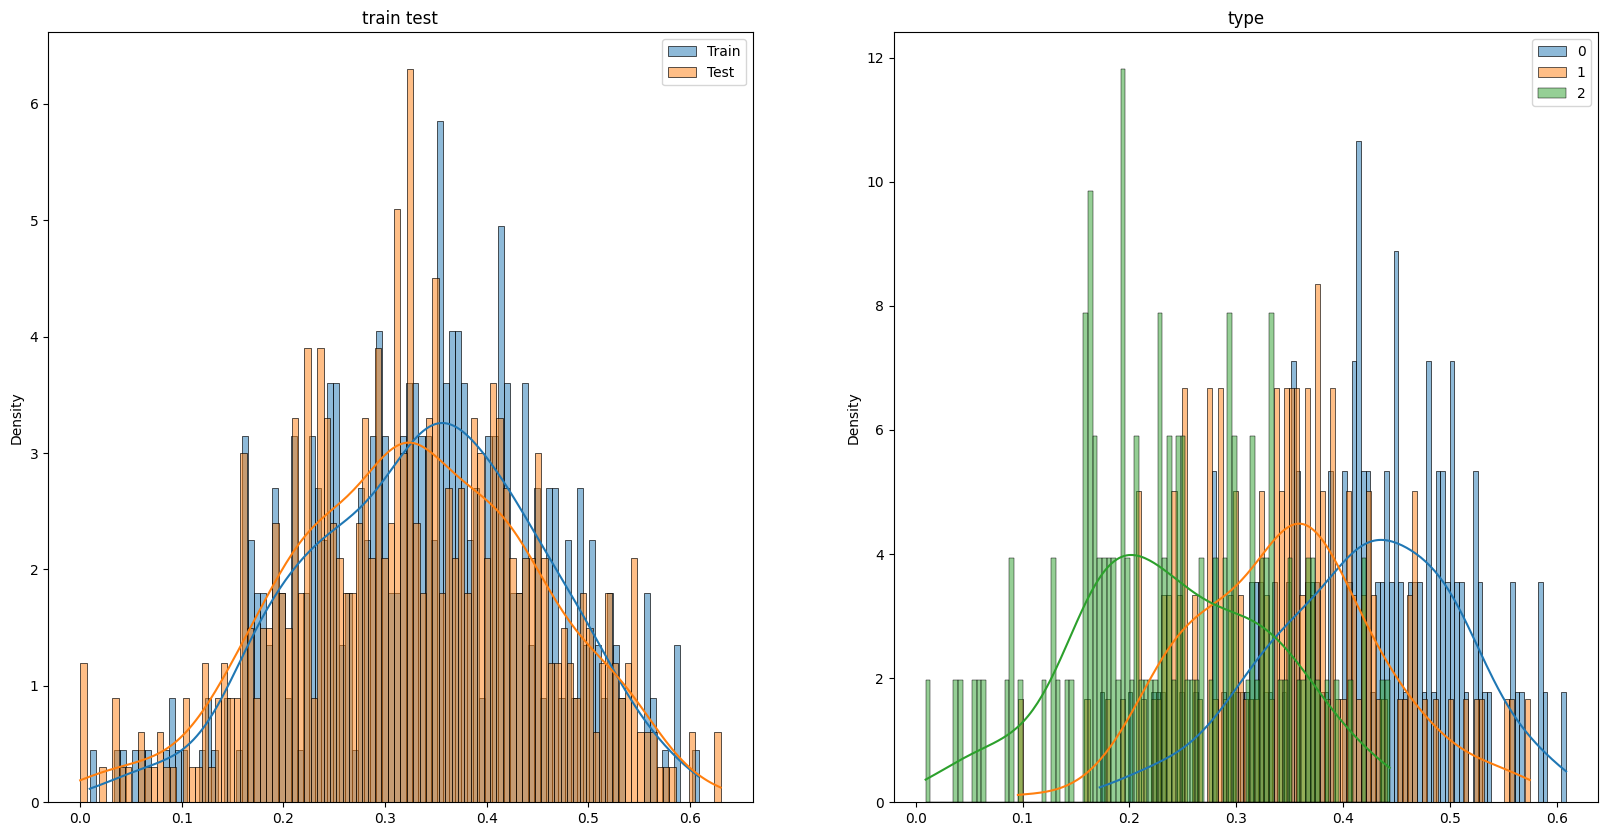

In [39]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].min(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].min(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].min(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Max

<Figure size 640x480 with 0 Axes>

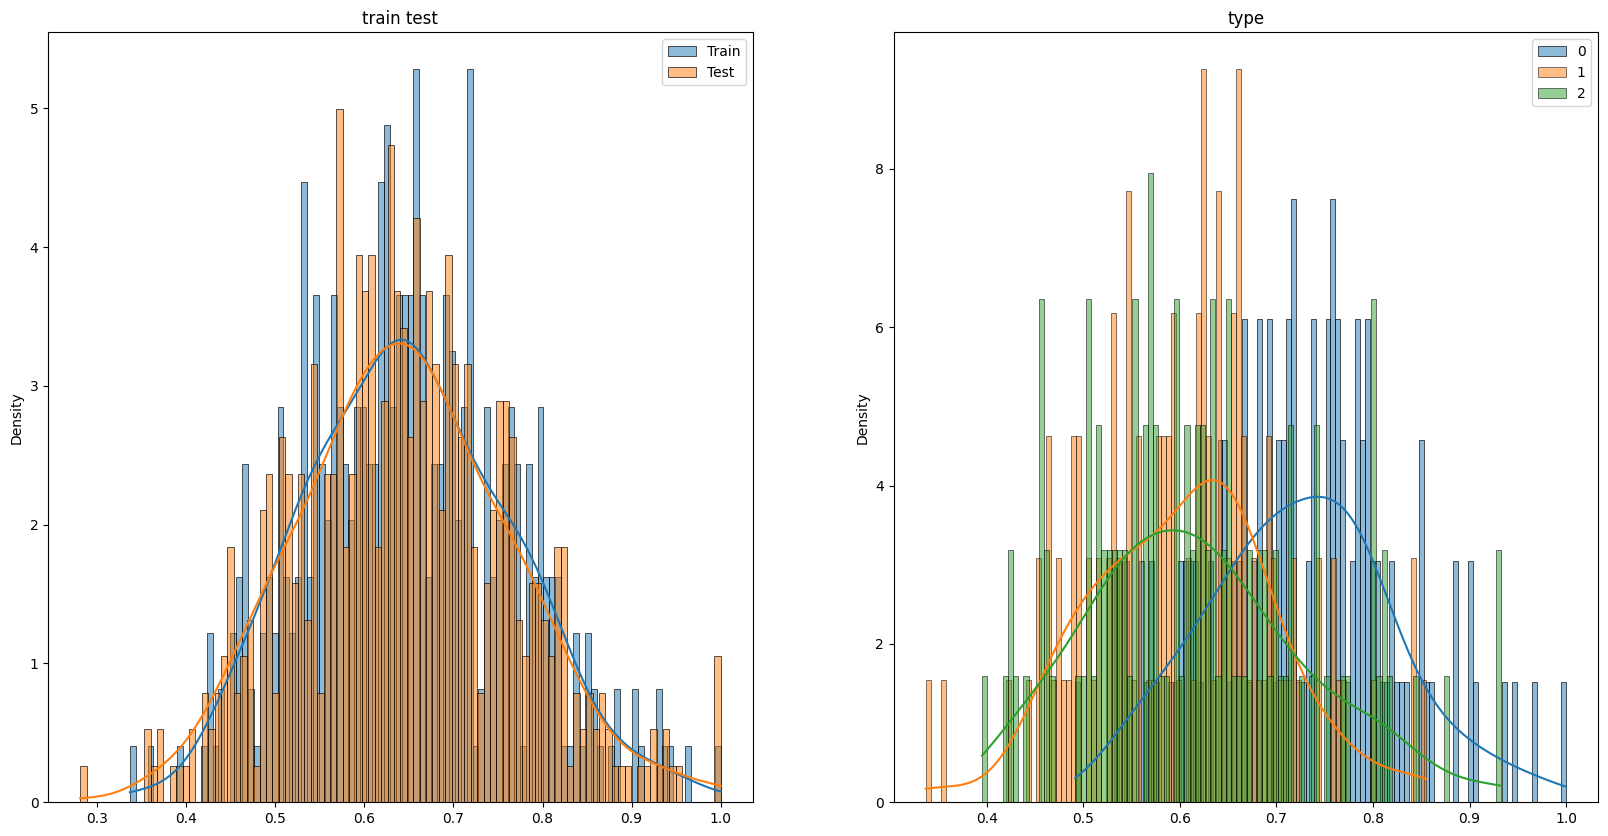

In [40]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].max(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].max(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].max(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Medain

<Figure size 640x480 with 0 Axes>

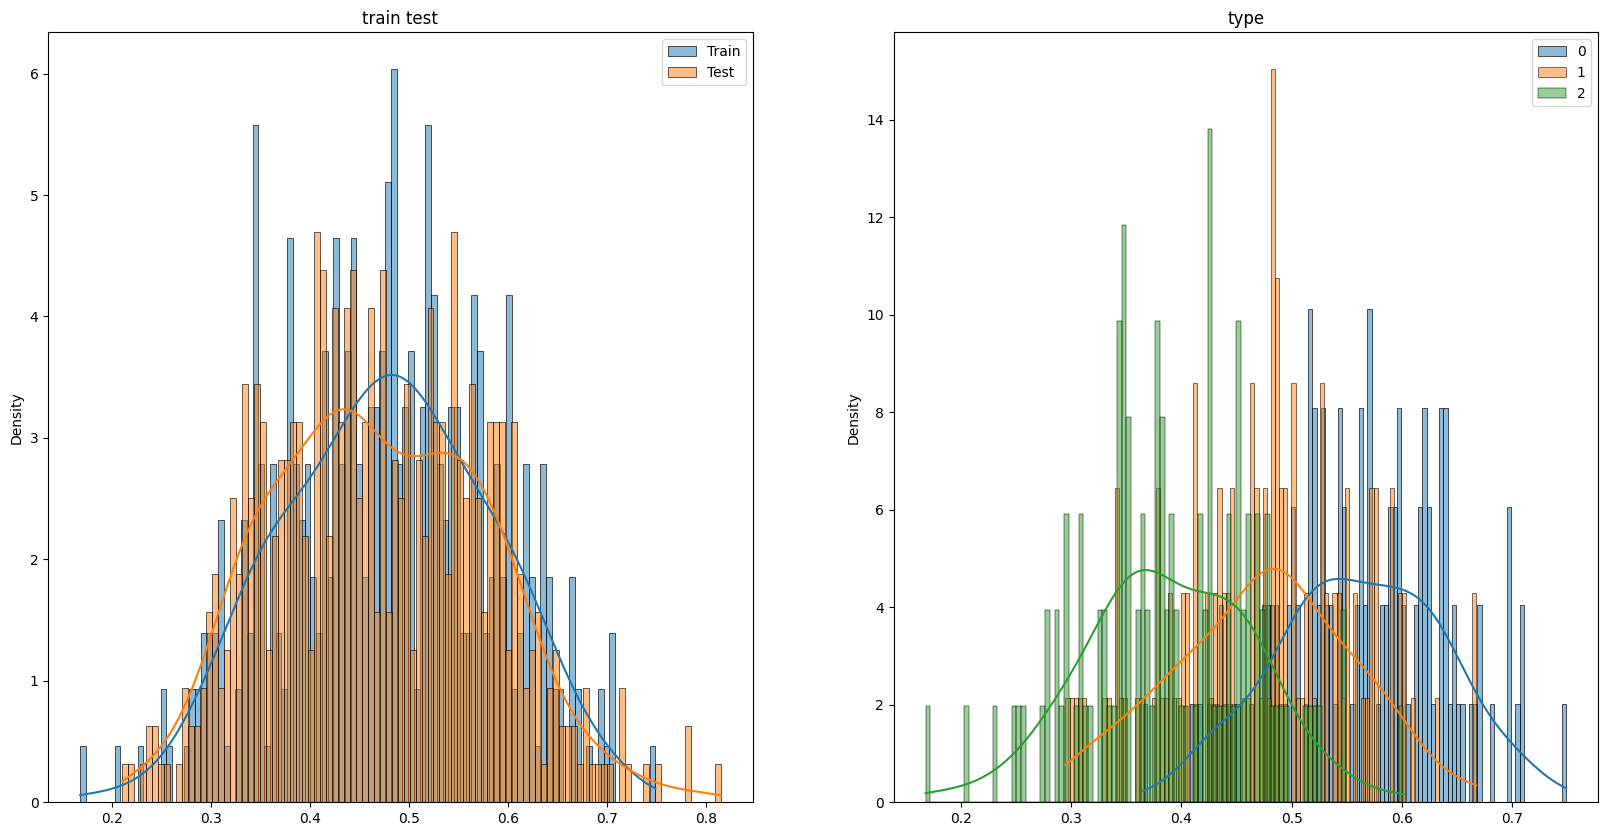

In [41]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].median(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].median(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].median(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Summary

<Figure size 640x480 with 0 Axes>

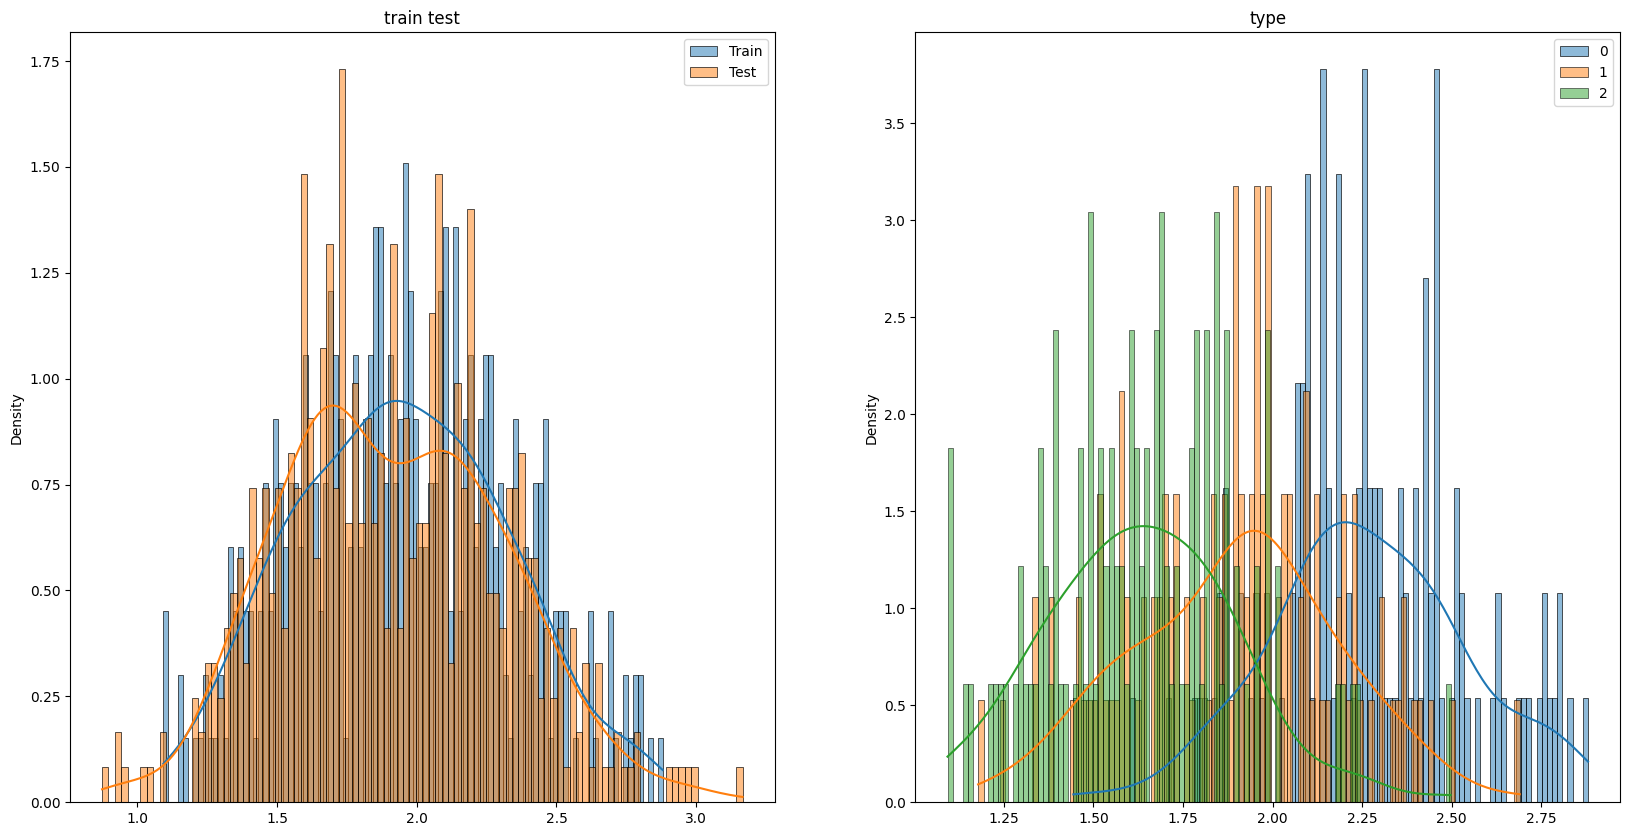

In [42]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].sum(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].sum(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].sum(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Skew

<Figure size 640x480 with 0 Axes>

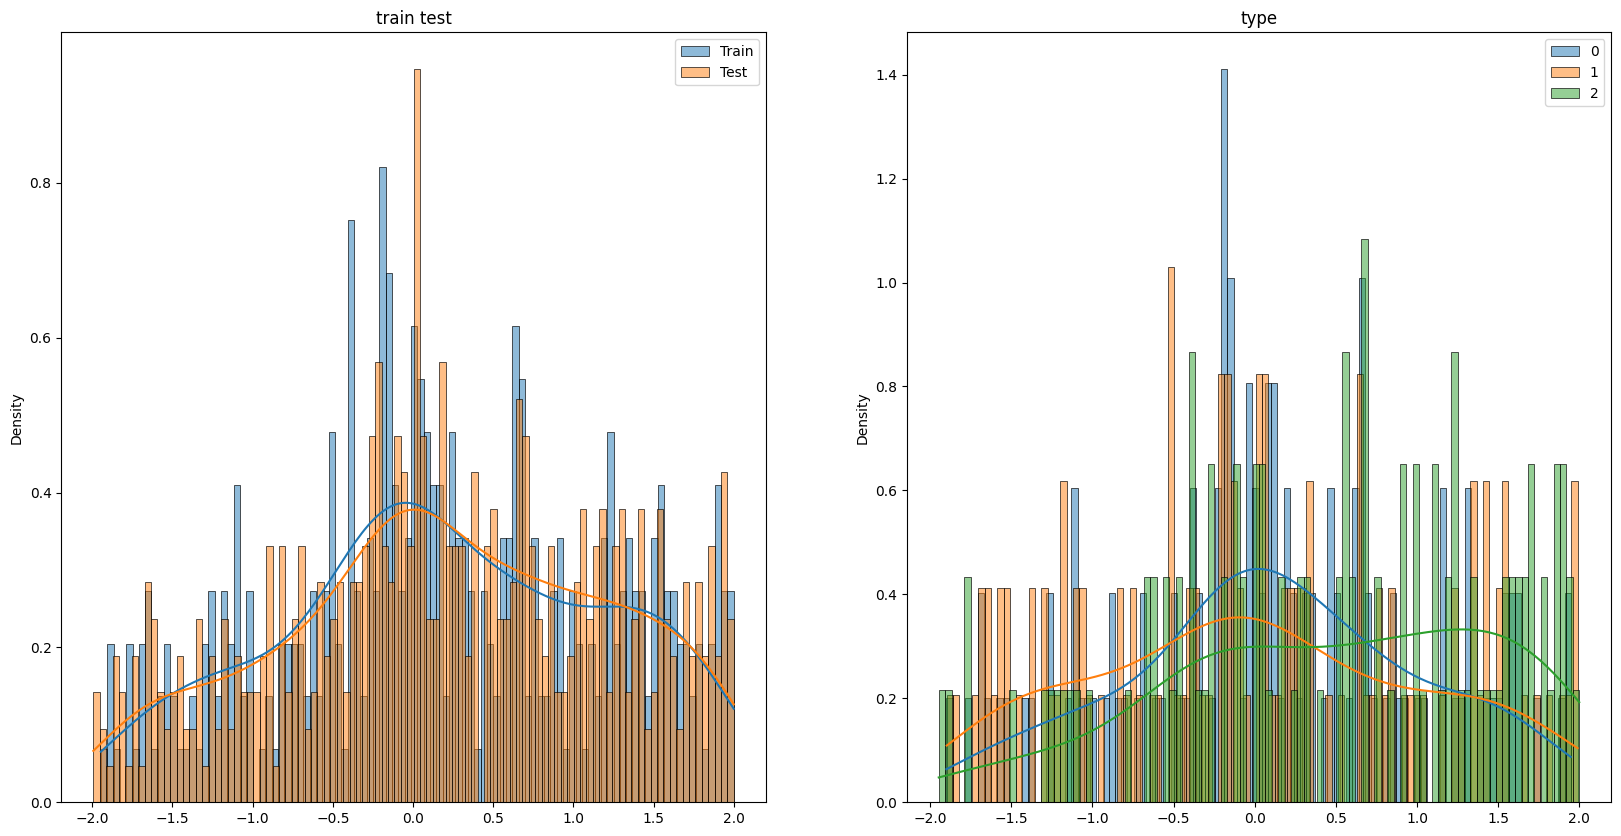

In [43]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].skew(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].skew(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].skew(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Kurtosis

<Figure size 640x480 with 0 Axes>

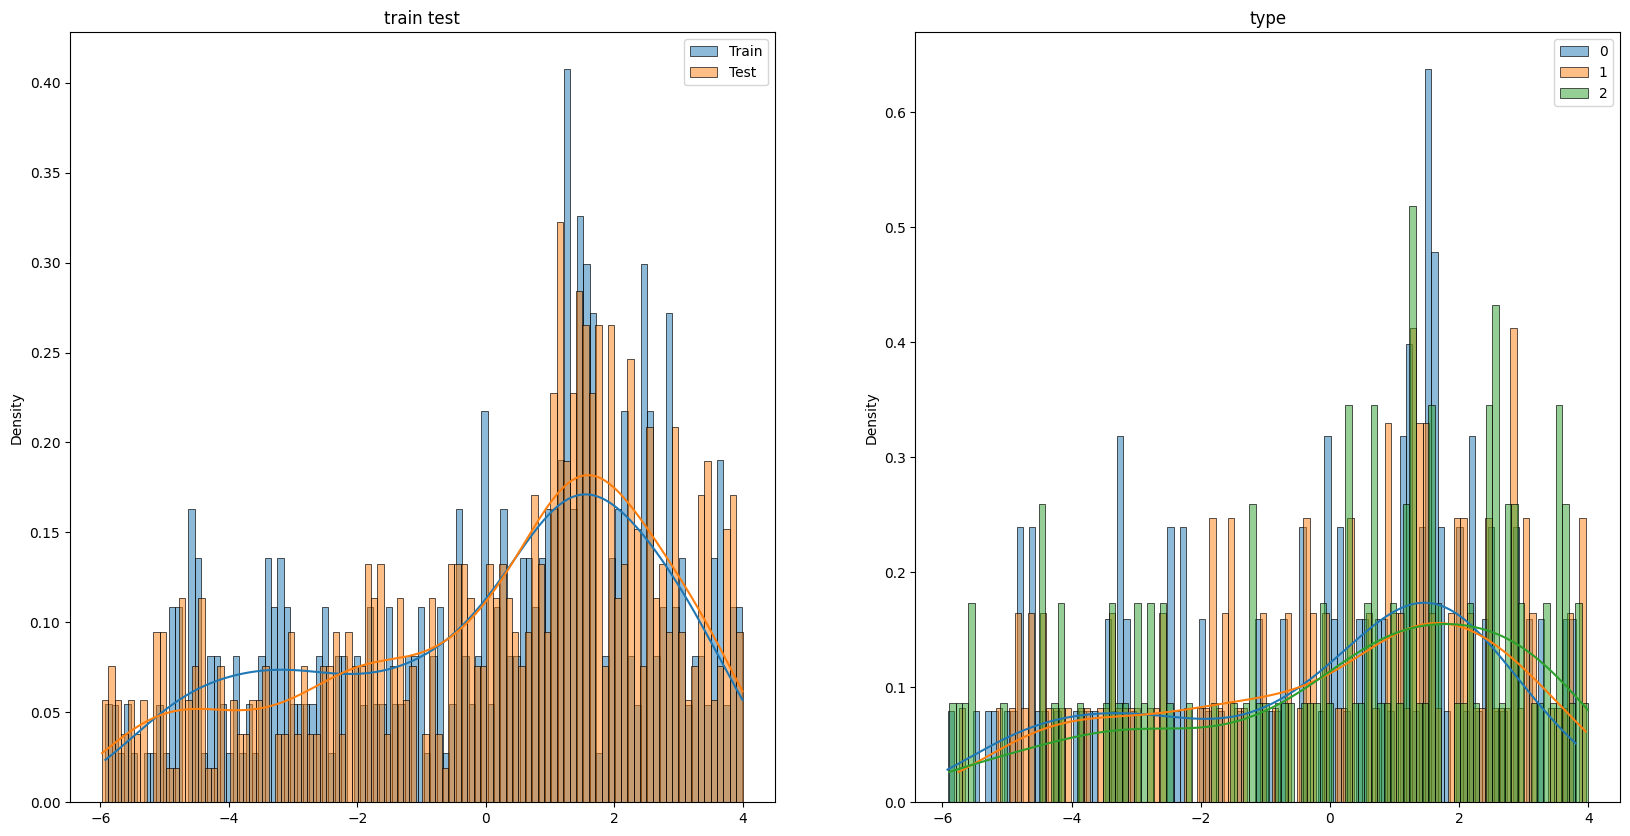

In [44]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[1:5]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].kurt(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].kurt(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['type'].nunique()
plt.subplot(1,2,2)
plt.title("type")
for i in range(uni):
    sns.histplot(data = train_df[train_df['type'] == i][features].kurt(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Correlation

In [71]:
num = train_df.select_dtypes(include=['int64', 'float64'])
num = num.drop(columns=['id'])

In [70]:
corr = num.corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
corr = corr[corr['level_0'] != corr['level_1']]

In [72]:
corr

,level_0,level_1,0
5,hair_length,type,0.674640
6,type,hair_length,0.674640
7,has_soul,type,0.649989
8,type,has_soul,0.649989
9,bone_length,type,0.520687
10,type,bone_length,0.520687
11,has_soul,hair_length,0.474835
12,hair_length,has_soul,0.474835
13,has_soul,bone_length,0.381675
14,bone_length,has_soul,0.381675


# **Feature Engineering**

In [73]:
def feature_engineer(df):
    df['mean'] = df[features].mean(axis=1)
    df['min'] = df[features].min(axis=1)
    df['max'] = df[features].max(axis=1)
    df['std'] = df[features].std(axis=1)
    df['median'] = df[features].median(axis=1)
    df['sum'] = df[features].sum(axis=1)
    df['skew'] = df[features].skew(axis=1)

In [74]:
for df in train_df, test_df:
    feature_engineer(df)
train_df.drop(columns=["id"], inplace=True)
test_df.drop(columns=["id"], inplace=True)

In [76]:
train_df.head()

,bone_length,rotting_flesh,hair_length,has_soul,color,type,mean,min,max,std,median,sum,skew
0,0.354512,0.350839,0.465761,0.781142,clear,0,0.488063,0.350839,0.781142,0.202533,0.410137,1.952254,1.620707
1,0.575560,0.425868,0.531401,0.439899,green,1,0.493182,0.425868,0.575560,0.072150,0.485650,1.972729,0.281451
2,0.467875,0.354330,0.811616,0.791225,black,0,0.606262,0.354330,0.811616,0.230219,0.629550,2.425047,-0.199556
3,0.776652,0.508723,0.636766,0.884464,black,0,0.701651,0.508723,0.884464,0.163786,0.706709,2.806604,-0.140000
4,0.566117,0.875862,0.418594,0.636438,green,2,0.624252,0.418594,0.875862,0.190728,0.601277,2.497010,0.676032


In [77]:
test_df.head()

,bone_length,rotting_flesh,hair_length,has_soul,color,mean,min,max,std,median,sum,skew
0,0.471774,0.387937,0.706087,0.698537,black,0.566084,0.387937,0.706087,0.161013,0.585156,2.264335,-0.227524
1,0.427332,0.645024,0.565558,0.451462,white,0.522344,0.427332,0.645024,0.101603,0.508510,2.089375,0.453351
2,0.549602,0.491931,0.660387,0.449809,black,0.537932,0.449809,0.660387,0.091311,0.520766,2.151729,0.924831
3,0.638095,0.682867,0.471409,0.356924,white,0.537324,0.356924,0.682867,0.150805,0.554752,2.149296,-0.398675
4,0.361762,0.583997,0.377256,0.276364,black,0.399845,0.276364,0.583997,0.130538,0.369509,1.599380,1.287390


# **Model**

In [ ]:
label = 'type'
metric = 'accuracy'
predictor = TabularPredictor(label=label, eval_metric=metric).fit(
    train_data = train_df,
    time_limit = 3600,
    presets = 'best_quality'
)

# **Evaluation**

In [ ]:
predictor.leaderboard(train_df,silent = True)

In [ ]:
predictor.evaluate(train_df)

In [ ]:
predictions = predictor.predict(test_df)

# **Submission**

In [79]:
zipfile.ZipFile("/home/drasogun/DraSoGun/AI/SuperAI_ss6/Competitions/Ghouls-Goblins-And-Ghosts-Boo/sample_submission.csv.zip").extractall("sub")

In [81]:
sam_sub = pd.read_csv('sub/sample_submission.csv')
sam_sub

,id,type
0,3,Ghost
1,6,Ghost
2,9,Ghost
3,10,Ghost
4,13,Ghost
...,...,...
524,893,Ghost
525,894,Ghost
526,895,Ghost
527,898,Ghost


In [ ]:
sub = pd.DataFrame({
    'id' : sam_sub['id'],
    'type' : predictions
})
sub.head()

In [ ]:
sub.to_csv('submission.csv', index=False)